In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, r2_score, confusion_matrix , mean_squared_error, ConfusionMatrixDisplay
import plotly.express as px


df = pd.read_excel('../data_sets/datos_limpios.xlsx')


In [2]:
df.dtypes

id                           int64
default                      int64
idade                        int64
sexo                           str
dependentes                  int64
escolaridade                   str
estado_civil                   str
salario_anual                  str
tipo_cartao                    str
meses_de_relacionamento      int64
qtd_produtos                 int64
iteracoes_12m                int64
meses_inativo_12m            int64
limite_credito             float64
valor_transacoes_12m       float64
qtd_transacoes_12m           int64
dtype: object

In [3]:
"""cols_numericas = df.select_dtypes(include='number') # ejemplo
for col in cols_numericas:
    fig = px.box(df, x='default', y=col, points="all",
                 title=f"{col} vs Default")
    fig.show()"""

'cols_numericas = df.select_dtypes(include=\'number\') # ejemplo\nfor col in cols_numericas:\n    fig = px.box(df, x=\'default\', y=col, points="all",\n                 title=f"{col} vs Default")\n    fig.show()'

In [4]:
fig = px.imshow(df.select_dtypes(include='number').corr(), text_auto=True, color_continuous_scale='RdBu_r',
                title="Matriz de Correlación Interactiva")
fig.show()

In [5]:
df.select_dtypes(include='number').corr()['default']

id                        -0.046430
default                    1.000000
idade                      0.018203
dependentes                0.018991
meses_de_relacionamento    0.013687
qtd_produtos              -0.150005
iteracoes_12m              0.204491
meses_inativo_12m          0.152449
limite_credito            -0.023873
valor_transacoes_12m      -0.168599
qtd_transacoes_12m        -0.371403
Name: default, dtype: float64

In [6]:
X_todo = df.select_dtypes(include='number').drop(columns=['default','id'])
X = df.select_dtypes(include='number').drop(columns=['default','id'])
y= df['default']

In [7]:
X.dtypes

idade                        int64
dependentes                  int64
meses_de_relacionamento      int64
qtd_produtos                 int64
iteracoes_12m                int64
meses_inativo_12m            int64
limite_credito             float64
valor_transacoes_12m       float64
qtd_transacoes_12m           int64
dtype: object

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.50, random_state=42)
modelo = SVC(kernel='linear')

In [9]:
modelo.fit(X_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [10]:
y_pred =modelo.predict(X_test)

In [11]:
acc = accuracy_score(y_test, y_pred)
mtr = confusion_matrix(y_test, y_pred)

print(f'el acc es: {acc}')
print(f'la matris es: {mtr}')

el acc es: 0.860387045813586
la matris es: [[4060  189]
 [ 518  297]]


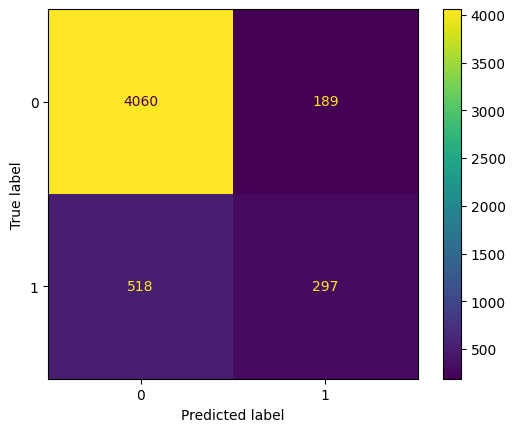

In [12]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

In [13]:
y_pred_real = modelo.predict(X_todo)

acc_2 = accuracy_score(y_test, y_pred)
mtr_2 = confusion_matrix(y_test, y_pred)

print(f'el acc es: {acc_2}')
print(f'la matris es: {mtr_2}')

el acc es: 0.860387045813586
la matris es: [[4060  189]
 [ 518  297]]


In [15]:
df['prediciones'] = y_pred_real

In [16]:
df.head()

,id,default,idade,sexo,dependentes,escolaridade,estado_civil,salario_anual,tipo_cartao,meses_de_relacionamento,qtd_produtos,iteracoes_12m,meses_inativo_12m,limite_credito,valor_transacoes_12m,qtd_transacoes_12m,prediciones
0,768805383,0,45,M,3,ensino medio,casado,60000 - 80000,blue,39,5,3,1,12691.51,1144.90,42,0
1,818770008,0,49,F,5,mestrado,solteiro,0 - 40000,blue,44,6,2,1,8256.96,1291.45,33,0
2,713982108,0,51,M,3,mestrado,casado,80000 - 120000,blue,36,4,0,1,3418.56,1887.72,20,0
3,769911858,0,40,F,4,ensino medio,<bound method Series.mode of 0 casa...,0 - 40000,blue,34,3,1,4,3313.03,1171.56,20,1
4,709106358,0,40,M,3,sem educacao formal,casado,60000 - 80000,blue,21,5,0,1,4716.22,816.08,28,0


In [17]:
df.to_excel('../data_sets/datos_limpios.xlsx', index=False, sheet_name='hoja_1')